## Import Library

In [1]:
import string
import re
import pandas as pd
import matplotlib.pyplot as plt

import csv
import requests
from io import StringIO
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemover
from wordcloud import WordCloud

## Load dataset

In [2]:
df = pd.read_csv('review_beyond_apps.csv')
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7be0671a-69ce-42c0-868f-9559db8db7a4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan lebih fresh...ada tapinya: jumlah rek...,4,27,1.2.1,2026-01-15 07:12:42,"Assalamualaikum Bapak/Ibu, mohon maaf untuk ke...",2026-01-15 07:16:21,1.2.1
1,f12959f9-e2c3-4310-956c-63268bef79bb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi lemot, sering bgt eror. mana sering k...",1,26,1.2.1,2026-01-20 21:18:00,"Assalamualaikum Ibu Lina, mohon maaf atas keti...",2026-01-20 21:22:17,1.2.1
2,e2439805-035e-4863-9696-4fa7b0f1626b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"baru terima transaksi dari bank, mau coba tran...",1,26,1.2.1,2026-01-11 12:00:46,"Assalamualaikum Bapak Hidayah, mohon maaf atas...",2026-01-11 13:00:54,1.2.1
3,a8aceae9-08e9-460c-8348-ed63da3e3b53,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"- aplikasi sering eror, mau log in kadang ga b...",1,7,1.2.1,2026-01-20 21:19:30,"Assalamualaikum Ibu Hasna, mohon maaf atas ata...",2026-01-20 21:35:12,1.2.1
4,2346d7f1-27fd-422e-819c-b04f24172d4e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,fitur byond mmg lengkap....tp sy sering terken...,4,18,1.2.1,2026-01-07 08:07:03,Assalamualaikum Kak Muhidin. Mohon maaf atas k...,2026-01-07 08:34:13,1.2.1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48886 entries, 0 to 48885
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              48886 non-null  object
 1   userName              48886 non-null  object
 2   userImage             48886 non-null  object
 3   content               48886 non-null  object
 4   score                 48886 non-null  int64 
 5   thumbsUpCount         48886 non-null  int64 
 6   reviewCreatedVersion  40998 non-null  object
 7   at                    48886 non-null  object
 8   replyContent          48618 non-null  object
 9   repliedAt             48618 non-null  object
 10  appVersion            40998 non-null  object
dtypes: int64(2), object(9)
memory usage: 4.1+ MB


In [4]:
new_df = df.dropna()
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40775 entries, 0 to 47861
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              40775 non-null  object
 1   userName              40775 non-null  object
 2   userImage             40775 non-null  object
 3   content               40775 non-null  object
 4   score                 40775 non-null  int64 
 5   thumbsUpCount         40775 non-null  int64 
 6   reviewCreatedVersion  40775 non-null  object
 7   at                    40775 non-null  object
 8   replyContent          40775 non-null  object
 9   repliedAt             40775 non-null  object
 10  appVersion            40775 non-null  object
dtypes: int64(2), object(9)
memory usage: 3.7+ MB


## Preprocessing

In [5]:
# Cleaning Text
def clean_text(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

# Casefolding text
def casefolding_text(text):
    text = text.lower()
    return text

# Tokenisasi text
def tokenization_text(text):
    text = word_tokenize(text)
    return text

# Filtering text
def filtering_text(text):
    word = ['yg','dg','rt','dgn','ny','klo','kalo','amp',
        'aja','nih','sih','deh','dong','kok','lah','mah',
        'nya','ku','mu','gw','gue','gua','loe','lu',
        'ga','gak','nggak','ngga','enggak','tdk','tak',
        'iya','ya','yaa','ok','oke',
        'loh','lho','kah','woi','woy','woii']
    stopwords_list = set(stopwords.words('indonesian'))
    stopwords_list_en = set(stopwords.words('english'))
    stopwords_list.update(stopwords_list_en)
    stopwords_list.update(word)
    filtered = []
    for txt in text:
        if txt not in stopwords_list:
            filtered.append(txt)
    text = filtered
    return text

# Stemming text
def stemming_text(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    list_word = text.split()
    stemmed_words = [stemmer.stem(word) for word in list_word]
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

# Convert text to sentence
def text_to_sentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence


In [6]:
slang_word = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin", "ga": "tidak", "gak": "tidak", "nggak": "tidak", "ngga": "tidak", "tdk": "tidak", "tak": "tidak", "bkn": "bukan", "yg": "yang", "aja": "saja", "ajaah": "saja", "udh": "sudah", "udah": "sudah", "blm": "belum", "belom": "belum", "dr": "dari", "krn": "karena", "karna": "karena", "dgn": "dengan", "jg": "juga", "lg": "lagi", "lgi": "lagi", "tp": "tapi", "tpi": "tapi", "trs": "terus", "trus": "terus", "sampe": "sampai", "ampe": "sampai", "bgt": "banget", "bgtt": "banget", "bgttt": "banget", "bngt": "banget", "lemot": "lambat", "lelet": "lambat", "lag": "lambat", "ngelag": "lambat", "error": "error", "eror": "error", "bug": "bug", "forceclose": "force close", "fc": "force close", "mantap": "bagus", "mantep": "bagus", "keren": "bagus", "oke": "bagus", "ok": "bagus", "parah": "buruk", "jelek": "buruk", "payah": "buruk", "kecewa": "kecewa", "update": "perbarui", "diupdate": "perbarui", "updatean": "perbarui", "login": "masuk", "logout": "keluar", "signout": "keluar", "signup": "daftar", "register": "daftar", "install": "pasang", "uninstall": "hapus", "gabisa": "tidak bisa", "gabisabuka": "tidak bisa buka", "gakbisa": "tidak bisa", "gausah": "tidak perlu", "kepake": "terpakai", "kepakai": "terpakai", "kepakek": "terpakai", "wkwk": "tertawa", "haha": "tertawa", "hehe": "tertawa", "lol": "tertawa", "apk": "aplikasi", "apps": "aplikasi", "app": "aplikasi", "pls": "tolong", "plis": "tolong", "tolongdong": "tolong", "skrg": "sekarang", "skrng": "sekarang", "kmrn": "kemarin", "bisaaa": "bisa", "bagusss": "bagus", "jelekkn": "jelek"}

def fixed_slangwords(text):
    words = text.split()
    fixed_words_list = []

    for word in words:
        if word.lower() in slang_word:
            fixed_words_list.append(slang_word[word.lower()])
        else:
            fixed_words_list.append(word)
    
    fixed_text = ' '.join(fixed_words_list)
    return fixed_text

##### Membersihkan text

In [7]:
new_df['text_cleaning'] = new_df['content'].apply(clean_text)

C:\Users\Lilik Triawan\AppData\Local\Temp\ipykernel_16052\761216583.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['text_cleaning'] = new_df['content'].apply(clean_text)


##### Konfersi teks ke huruf kecil

In [8]:
new_df['text_casefolding'] = new_df['text_cleaning'].apply(casefolding_text)

C:\Users\Lilik Triawan\AppData\Local\Temp\ipykernel_16052\1563527512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['text_casefolding'] = new_df['text_cleaning'].apply(casefolding_text)


##### Ubah kata-kata slang menjadi kata asli

In [9]:
new_df['text_slangwords'] = new_df['text_casefolding'].apply(fixed_slangwords)

C:\Users\Lilik Triawan\AppData\Local\Temp\ipykernel_16052\2892418954.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['text_slangwords'] = new_df['text_casefolding'].apply(fixed_slangwords)


##### Memecah teks menjadi token

In [10]:
new_df['text_tokenized'] = new_df['text_slangwords'].apply(tokenization_text)

C:\Users\Lilik Triawan\AppData\Local\Temp\ipykernel_16052\1665677374.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['text_tokenized'] = new_df['text_slangwords'].apply(tokenization_text)


##### Hapus kata-kata yang tidak perlu

In [11]:
new_df['text_stopword'] = new_df['text_tokenized'].apply(filtering_text)

C:\Users\Lilik Triawan\AppData\Local\Temp\ipykernel_16052\2034109000.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['text_stopword'] = new_df['text_tokenized'].apply(filtering_text)


In [12]:
new_df['final_text'] = new_df['text_stopword'].apply(text_to_sentence)

C:\Users\Lilik Triawan\AppData\Local\Temp\ipykernel_16052\2132625523.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['final_text'] = new_df['text_stopword'].apply(text_to_sentence)


In [13]:
new_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_cleaning,text_casefolding,text_slangwords,text_tokenized,text_stopword,final_text
0,7be0671a-69ce-42c0-868f-9559db8db7a4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan lebih fresh...ada tapinya: jumlah rek...,4,27,1.2.1,2026-01-15 07:12:42,"Assalamualaikum Bapak/Ibu, mohon maaf untuk ke...",2026-01-15 07:16:21,1.2.1,Tampilan lebih freshada tapinya jumlah rekenin...,tampilan lebih freshada tapinya jumlah rekenin...,tampilan lebih freshada tapinya jumlah rekenin...,"[tampilan, lebih, freshada, tapinya, jumlah, r...","[tampilan, freshada, tapinya, rekening, terbat...",tampilan freshada tapinya rekening terbatas bu...
1,f12959f9-e2c3-4310-956c-63268bef79bb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi lemot, sering bgt eror. mana sering k...",1,26,1.2.1,2026-01-20 21:18:00,"Assalamualaikum Ibu Lina, mohon maaf atas keti...",2026-01-20 21:22:17,1.2.1,aplikasi lemot sering bgt eror mana sering kel...,aplikasi lemot sering bgt eror mana sering kel...,aplikasi lambat sering banget error mana serin...,"[aplikasi, lambat, sering, banget, error, mana...","[aplikasi, lambat, banget, error, bawa, tunai,...",aplikasi lambat banget error bawa tunai toko n...
2,e2439805-035e-4863-9696-4fa7b0f1626b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"baru terima transaksi dari bank, mau coba tran...",1,26,1.2.1,2026-01-11 12:00:46,"Assalamualaikum Bapak Hidayah, mohon maaf atas...",2026-01-11 13:00:54,1.2.1,baru terima transaksi dari bank mau coba trans...,baru terima transaksi dari bank mau coba trans...,baru terima transaksi dari bank mau coba trans...,"[baru, terima, transaksi, dari, bank, mau, cob...","[terima, transaksi, bank, coba, transaksi, buk...",terima transaksi bank coba transaksi buka apli...
3,a8aceae9-08e9-460c-8348-ed63da3e3b53,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"- aplikasi sering eror, mau log in kadang ga b...",1,7,1.2.1,2026-01-20 21:19:30,"Assalamualaikum Ibu Hasna, mohon maaf atas ata...",2026-01-20 21:35:12,1.2.1,aplikasi sering eror mau log in kadang ga bisa...,aplikasi sering eror mau log in kadang ga bisa...,aplikasi sering error mau log in kadang tidak ...,"[aplikasi, sering, error, mau, log, in, kadang...","[aplikasi, error, log, kadang, error, kali, tr...",aplikasi error log kadang error kali transfer ...
4,2346d7f1-27fd-422e-819c-b04f24172d4e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,fitur byond mmg lengkap....tp sy sering terken...,4,18,1.2.1,2026-01-07 08:07:03,Assalamualaikum Kak Muhidin. Mohon maaf atas k...,2026-01-07 08:34:13,1.2.1,fitur byond mmg lengkaptp sy sering terkendala...,fitur byond mmg lengkaptp sy sering terkendala...,fitur byond mmg lengkaptp saya sering terkenda...,"[fitur, byond, mmg, lengkaptp, saya, sering, t...","[fitur, byond, mmg, lengkaptp, terkendala, byo...",fitur byond mmg lengkaptp terkendala byond tra...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47857,0d5bfdd3-3771-46f2-b16e-d7e86e4cb617,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍,5,0,1.0.1,2025-01-16 06:37:51,"Assalamualaikum Bapak Setiawan, terima kasih a...",2025-01-16 09:11:13,1.0.1,,,,[],[],
47858,4b24cb7b-a7f3-485a-94c5-0716ce2b6e7b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍,5,0,1.0.1,2024-10-26 12:49:54,Assalamualaikum Bapak Rio terima kasih atas ul...,2024-10-27 09:35:05,1.0.1,,,,[],[],
47859,efcb3bc9-1bba-4e1a-8d65-8aafb14922ab,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍👍👍👍,5,0,1.0.1,2024-10-25 23:04:16,"Assalamualaikum Bapak Angga, terima kasih atas...",2024-11-11 12:07:46,1.0.1,,,,[],[],
47860,2842f0a6-2814-483b-8c79-bd19634632c1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Nice👍👍👍👍👍,5,0,1.0.1,2024-10-27 04:55:41,"Assalamualaikum Ibu Fatimah, terima kasih ata

## Pelabelan data

##### Load data lexicon positif dan negatif dari github

In [14]:
# load positif
lex_postive = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lex_postive[row[0]] = int(row[1])
else:
    print("Gagal mengambil data data lexicon positif")


# load negatif
lex_negative = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lex_negative[row[0]] = int(row[1])
else:
    print("Gagal mengambil data data lexicon negatif")

In [15]:
def sentiment_analysis_lexicon_id(text):
    point_score = 0
    for word in text:
        if (word in lex_postive):
            point_score = point_score + lex_postive[word]

    for word in text:
        if (word in lex_negative):
            point_score = point_score + lex_negative[word]

    polarity=''
    if (point_score > 0):
        polarity = 'positive'
    elif (point_score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'
    
    return point_score, polarity


In [16]:
res = new_df['text_stopword'].apply(sentiment_analysis_lexicon_id)
res = list(zip(*res))
new_df['polarity_score'] = res[0]
new_df['polarity'] = res[1]
print(new_df['polarity'].value_counts())

polarity
negative    23075
positive    12907
neutral      4793
Name: count, dtype: int64


C:\Users\Lilik Triawan\AppData\Local\Temp\ipykernel_16052\3512612439.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['polarity_score'] = res[0]
C:\Users\Lilik Triawan\AppData\Local\Temp\ipykernel_16052\3512612439.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['polarity'] = res[1]


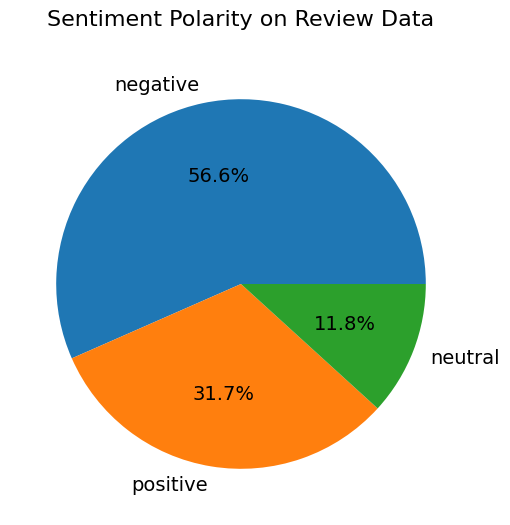

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
sizes = [count for count in new_df['polarity'].value_counts()]
labels = list(new_df['polarity'].value_counts().index)
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)
plt.show()

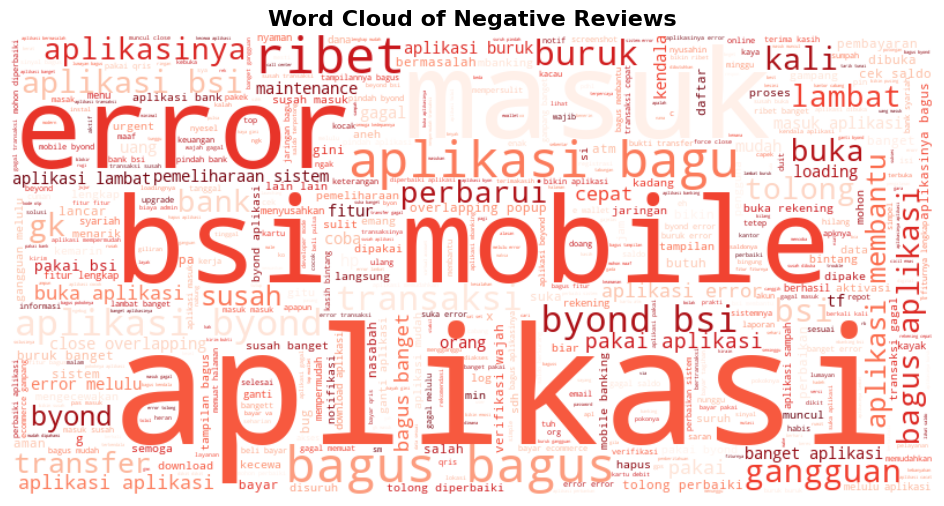

In [18]:
negative_reviews = new_df[new_df['polarity'] == 'negative']
negative_text = ' '.join(negative_reviews['text_stopword'].astype(str).tolist())
negative_text = negative_text.replace("'", "").replace('"', "")

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=500,
    random_state=42
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Word Cloud of Negative Reviews', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

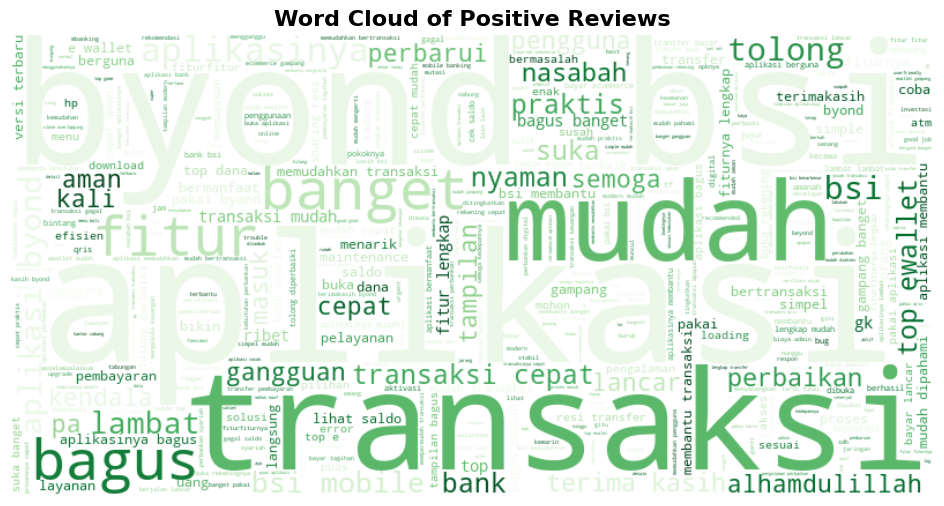

In [19]:
positive_reviews = new_df[new_df['polarity'] == 'positive']
positive_text = ' '.join(positive_reviews['text_stopword'].astype(str).tolist())
positive_text = positive_text.replace("'", "").replace('"', "")

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    max_words=500,
    random_state=42
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Word Cloud of Positive Reviews', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

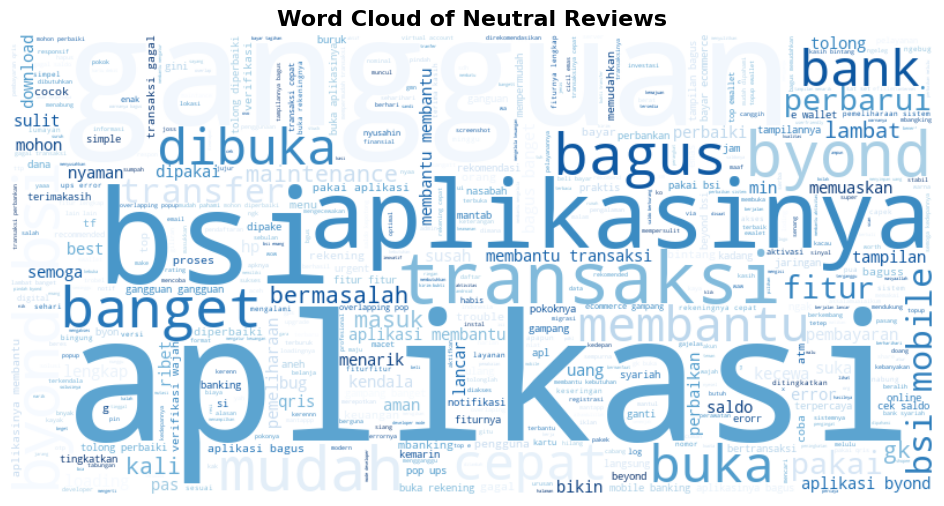

In [20]:
neutral_reviews = new_df[new_df['polarity'] == 'neutral']
neutral_text = ' '.join(neutral_reviews['text_stopword'].astype(str).tolist())
neutral_text = neutral_text.replace("'", "").replace('"', "")

wordcloud_neutral = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Blues',
    max_words=500,
    random_state=42
).generate(neutral_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.title('Word Cloud of Neutral Reviews', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

## Data Splitting

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score
from sklearn.linear_model import LogisticRegression

In [22]:
new_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_cleaning,text_casefolding,text_slangwords,text_tokenized,text_stopword,final_text,polarity_score,polarity
0,7be0671a-69ce-42c0-868f-9559db8db7a4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Tampilan lebih fresh...ada tapinya: jumlah rek...,4,27,1.2.1,2026-01-15 07:12:42,"Assalamualaikum Bapak/Ibu, mohon maaf untuk ke...",2026-01-15 07:16:21,1.2.1,Tampilan lebih freshada tapinya jumlah rekenin...,tampilan lebih freshada tapinya jumlah rekenin...,tampilan lebih freshada tapinya jumlah rekenin...,"[tampilan, lebih, freshada, tapinya, jumlah, r...","[tampilan, freshada, tapinya, rekening, terbat...",tampilan freshada tapinya rekening terbatas bu...,-21,negative
1,f12959f9-e2c3-4310-956c-63268bef79bb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi lemot, sering bgt eror. mana sering k...",1,26,1.2.1,2026-01-20 21:18:00,"Assalamualaikum Ibu Lina, mohon maaf atas keti...",2026-01-20 21:22:17,1.2.1,aplikasi lemot sering bgt eror mana sering kel...,aplikasi lemot sering bgt eror mana sering kel...,aplikasi lambat sering banget error mana serin...,"[aplikasi, lambat, sering, banget, error, mana...","[aplikasi, lambat, banget, error, bawa, tunai,...",aplikasi lambat banget error bawa tunai toko n...,-2,negative
2,e2439805-035e-4863-9696-4fa7b0f1626b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"baru terima transaksi dari bank, mau coba tran...",1,26,1.2.1,2026-01-11 12:00:46,"Assalamualaikum Bapak Hidayah, mohon maaf atas...",2026-01-11 13:00:54,1.2.1,baru terima transaksi dari bank mau coba trans...,baru terima transaksi dari bank mau coba trans...,baru terima transaksi dari bank mau coba trans...,"[baru, terima, transaksi, dari, bank, mau, cob...","[terima, transaksi, bank, coba, transaksi, buk...",terima transaksi bank coba transaksi buka apli...,11,positive
3,a8aceae9-08e9-460c-8348-ed63da3e3b53,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"- aplikasi sering eror, mau log in kadang ga b...",1,7,1.2.1,2026-01-20 21:19:30,"Assalamualaikum Ibu Hasna, mohon maaf atas ata...",2026-01-20 21:35:12,1.2.1,aplikasi sering eror mau log in kadang ga bisa...,aplikasi sering eror mau log in kadang ga bisa...,aplikasi sering error mau log in kadang tidak ...,"[aplikasi, sering, error, mau, log, in, kadang...","[aplikasi, error, log, kadang, error, kali, tr...",aplikasi error log kadang error kali transfer ...,-14,negative
4,2346d7f1-27fd-422e-819c-b04f24172d4e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,fitur byond mmg lengkap....tp sy sering terken...,4,18,1.2.1,2026-01-07 08:07:03,Assalamualaikum Kak Muhidin. Mohon maaf atas k...,2026-01-07 08:34:13,1.2.1,fitur byond mmg lengkaptp sy sering terkendala...,fitur byond mmg lengkaptp sy sering terkendala...,fitur byond mmg lengkaptp saya sering terkenda...,"[fitur, byond, mmg, lengkaptp, saya, sering, t...","[fitur, byond, mmg, lengkaptp, terkendala, byo...",fitur byond mmg lengkaptp terkendala byond tra...,5,positive


In [23]:
X = new_df['final_text']
y = new_df['polarity']

In [24]:
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [25]:
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
features_df.head()

,admin,akses,aktivasi,akun,alhamdulillah,aman,aneh,apapun,aplikasi,aplikasinya,...,transaksinya,transfer,tunai,uang,ulang,urgent,verifikasi,versi,wajah,wallet
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.077307,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.199928,0.0,0.218613,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.088944,0.0,...,0.0,0.000000,0.282059,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.165308,0.0,...,0.0,0.000000,0.262113,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.113566,0.0,...,0.0,0.238573,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.115106,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

## Pemodelan Machine Learning

##### Logistic Regression

In [27]:
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train.toarray(), y_train)

y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8718884120171674
Logistic Regression - accuracy_test: 0.8648681790312691


##### Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train.toarray(), y_train)

y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())

accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

# Menampilkan akurasi
print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.9651747394236665
Decision Tree - accuracy_test: 0.7988963825873697


In [29]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()

random_forest.fit(X_train.toarray(), y_train)
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9651440833844267
Random Forest - accuracy_test: 0.8426732066217045


In [31]:
import pandas as pd

results_df = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'Decision Tree'],
    'Accuracy Train': [accuracy_train_rf, accuracy_train_lr, accuracy_train_dt],
    'Accuracy Test': [accuracy_test_rf, accuracy_test_lr, accuracy_test_dt]
})
accuracy_test_only = results_df[['Model', 'Accuracy Test']]
accuracy_test_sorted = accuracy_test_only.sort_values(by='Accuracy Test', ascending=False)
print(accuracy_test_sorted)

                 Model  Accuracy Test
1  Logistic Regression       0.864868
0        Random Forest       0.842673
2        Decision Tree       0.798896


##### Perbandingan Performa Model

## Deep Learning Algorithm for Sentiment Analysis

In [28]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import numpy as np

c:\Users\Lilik Triawan\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [29]:
print(new_df['polarity'].value_counts())

polarity
negative    23075
positive    12907
neutral      4793
Name: count, dtype: int64


In [30]:
# Tokenisasi
tokenizer = Tokenizer(num_words = 10000, oov_token="<OOV>")
tokenizer.fit_on_texts(new_df['final_text'])
word_index = tokenizer.word_index

In [31]:
# Mengubah Text ke Sequence
sequences = tokenizer.texts_to_sequences(new_df['final_text'])
padded = pad_sequences(sequences, maxlen=100, truncating='post')

In [32]:
# Label Encoding
label_encoder = LabelEncoder()
labels_integers = label_encoder.fit_transform(new_df['polarity'])

In [33]:
# Oversampling untuk mengatasi kelas yang tidak seimbang
ros = RandomOverSampler(random_state=42)
padded_resampled, labels_resampled = ros.fit_resample(padded, labels_integers)

print(f"Sebelum oversampling: {len(padded)} sampel")
print(f"Setelah oversampling: {len(padded_resampled)} sampel")

Sebelum oversampling: 40775 sampel
Setelah oversampling: 69225 sampel


In [35]:
# Split Data (80/20)
labels_one_hot = to_categorical(labels_resampled)
X_train, X_test, y_train, y_test = train_test_split(padded_resampled, labels_one_hot, test_size=0.2, random_state=42, stratify=labels_one_hot)

print(f"Data Latih: {X_train.shape}")
print(f"Data Uji: {X_test.shape}")

Data Latih: (55380, 100)
Data Uji: (13845, 100)


In [36]:
# Model LSTM dengan jumlah unit 128 untuk Sentiment Analysis
model = Sequential([
    Embedding(10000, 100, input_length=100),
    Bidirectional(LSTM(128, return_sequences=True)), 
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

c:\Users\Lilik Triawan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [37]:
# Optimizer model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [38]:
# Gunakan Callback untuk membandingkan train dan validasi accuracy lalu stop training jika sudah mencapai target
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
class TargetAccuracyCallback(Callback):
    def on_epoch_end(self, epoch, logs={}):
        train_accuray = logs.get('accuracy') 
        val_accuracy = logs.get('val_accuracy')
        if train_accuray > 0.93 and val_accuracy > 0.93:
            self.model.stop_training = True

target_stop = TargetAccuracyCallback()
early_stop_backup = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)

In [39]:
# Training model
reduce_learning_rate = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=3, min_lr=0.00001, verbose=1)

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), callbacks=[target_stop, reduce_learning_rate, early_stop_backup], verbose=1)

Epoch 1/10
1731/1731 ━━━━━━━━━━━━━━━━━━━━ 465s 265ms/step - accuracy: 0.8619 - loss: 0.3357 - val_accuracy: 0.9344 - val_loss: 0.1764 - learning_rate: 0.0010
Epoch 2/10
1731/1731 ━━━━━━━━━━━━━━━━━━━━ 391s 226ms/step - accuracy: 0.9522 - loss: 0.1286 - val_accuracy: 0.9569 - val_loss: 0.1262 - learning_rate: 0.0010


In [40]:
# Fungsi Visualisasi grafik akurasi dan loss
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'validasi '+string])
  plt.title(f"Grafik {string}")
  plt.show()

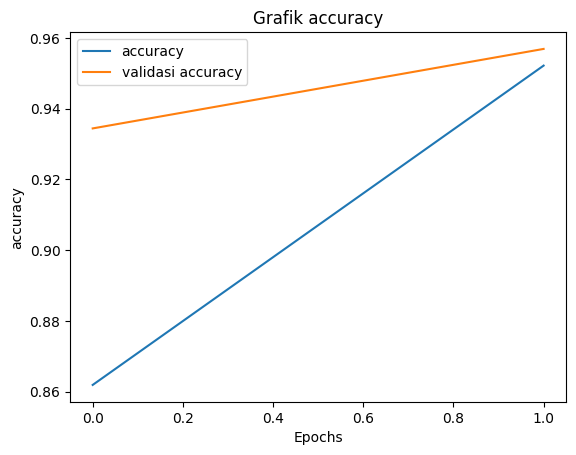

In [41]:
plot_graphs(history, "accuracy")

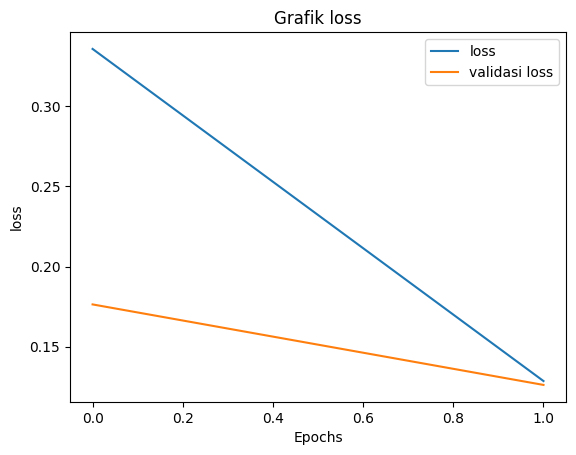

In [42]:

plot_graphs(history, "loss")

In [43]:
# Evaluation
loss, accuracy = model.evaluate(X_test, y_test)

433/433 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9569 - loss: 0.1262


In [44]:
# Inference Function
def prediction_sentiment(text):
    try:
        cleaning_text = clean_text(text)
        cleaning_text = casefolding_text(cleaning_text)
        cleaning_text = fixed_slangwords(cleaning_text)
        tokens = tokenization_text(cleaning_text)
        tokens = filtering_text(tokens)
        final_text = text_to_sentence(tokens)
    except NameError as e:
        final_text = text.lower()
    
    sequence = tokenizer.texts_to_sequences([final_text])
    padded_input = pad_sequences(sequence, maxlen=100, truncating='post')
    
    prediction = model.predict(padded_input)
    predicted_label_index = prediction.argmax(axis=1)[0]
    
    predicted_label = label_encoder.inverse_transform([predicted_label_index])[0]
    confidence = prediction[0][predicted_label_index]
    
    return predicted_label, confidence

In [51]:
# Inference
kalimat = [
    ("Terima kasih BSI, aplikasi lancar dan sangat membantu transaksi sehari-hari, mantap recommended!"),
    ("Alhamdulillah transfer cepat, fitur lengkap, sangat puas dengan pelayanan BSI mobile"),
    ("Aplikasi sering error, loading lama, transaksi gagal terus, sangat kecewa dan mengecewakan"),
    ("Lemot banget, tidak bisa login, sudah uninstall install masih bermasalah, parah"),
    ("Lumayan bagus aplikasinya, fiturnya juga cukup lengkap, jadi tergantung kebutuhan masing-masing penggguna."),
]

for sentence in kalimat:
    label, conf = prediction_sentiment(sentence)
    print(f"Input: {sentence}")
    print(f"Hasil Prediksi: {label.upper()} | Nilai Confidence: {conf:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Input: Terima kasih BSI, aplikasi lancar dan sangat membantu transaksi sehari-hari, mantap recommended!
Hasil Prediksi: POSITIVE | Nilai Confidence: 0.9957
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Input: Alhamdulillah transfer cepat, fitur lengkap, sangat puas dengan pelayanan BSI mobile
Hasil Prediksi: POSITIVE | Nilai Confidence: 0.9996
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Input: Aplikasi sering error, loading lama, transaksi gagal terus, sangat kecewa dan mengecewakan
Hasil Prediksi: NEGATIVE | Nilai Confidence: 0.9999
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Input: Lemot banget, tidak bisa login, sudah uninstall install masih bermasalah, parah
Hasil Prediksi: NEGATIVE | Nilai Confidence: 0.9998
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Input: Lumayan bagus aplikasinya, fiturnya juga cukup lengkap, jadi tergantung kebutuhan masing-masing penggguna.
Hasil Prediksi: NEUTRAL | Nilai Confidence: 0.4760
